In [ ]:
from google.colab import files

uploaded = files.upload()

Saving banking_data.csv to banking_data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import pandas as pd

df = pd.read_csv("banking_data.csv")

In [ ]:
df.head()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45216 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45216 non-null  int64 
 1   job             45216 non-null  object
 2   marital         45213 non-null  object
 3   marital_status  45213 non-null  object
 4   education       45213 non-null  object
 5   default         45216 non-null  object
 6   balance         45216 non-null  int64 
 7   housing         45216 non-null  object
 8   loan            45216 non-null  object
 9   contact         45216 non-null  object
 10  day             45216 non-null  int64 
 11  month           45216 non-null  object
 12  day_month       45216 non-null  object
 13  duration        45216 non-null  int64 
 14  campaign        45216 non-null  int64 
 15  pdays           45216 non-null  int64 
 16  previous        45216 non-null  int64 
 17  poutcome        45216 non-null  object
 18  y     

,age,balance,day,duration,campaign,pdays,previous
count,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000
mean,40.938186,1362.277844,15.806507,258.166202,2.763668,40.202428,0.580657
std,10.621249,3044.609674,8.322022,257.515482,3.097896,100.128248,2.303778
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.500000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,3
marital_status,3
education,3
default,0
balance,0
housing,0
loan,0
contact,0


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df = df.drop_duplicates()

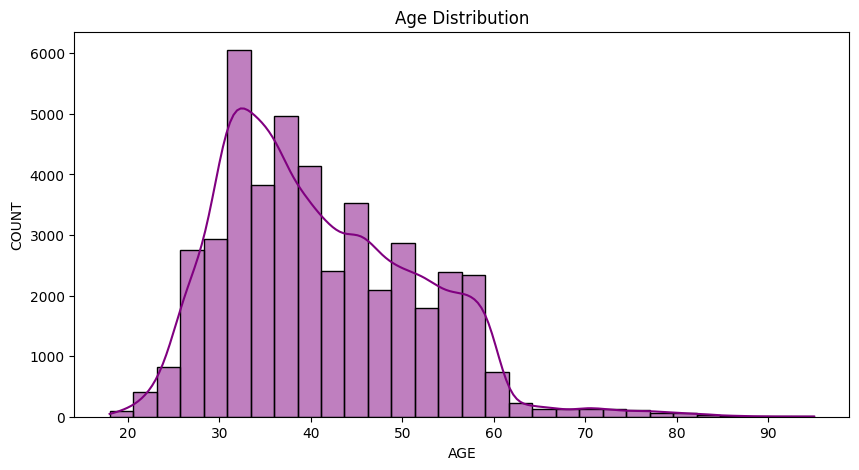

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins= 30, kde=True, color= "purple")
plt.title("Age Distribution")
plt.xlabel("AGE")
plt.ylabel("COUNT")

plt.show()
plt.figure()

In [ ]:
df["age"].describe()

,age
count,45211.000000
mean,40.936210
std,10.618762
min,18.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,95.000000


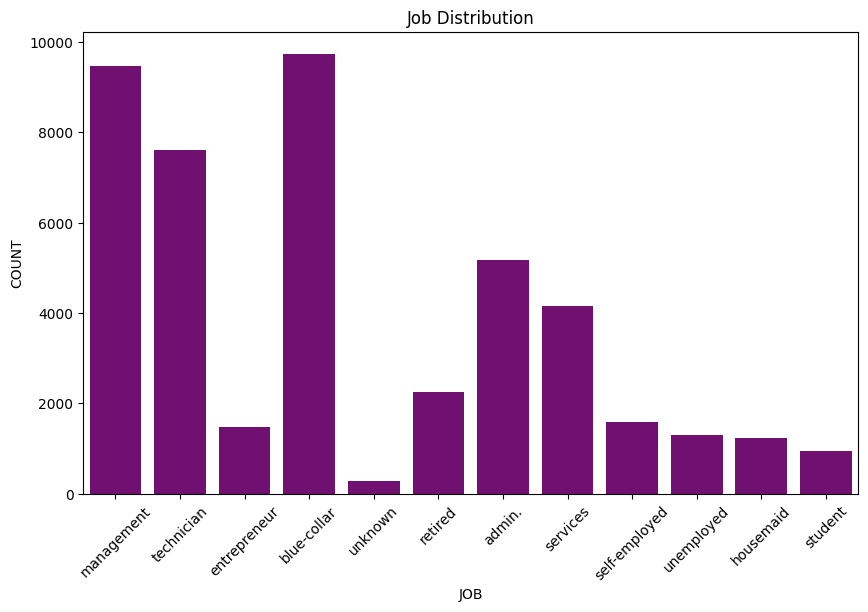

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='job', data=df,color="purple")
plt.xticks(rotation = 45)
plt.xlabel("JOB")
plt.ylabel("COUNT")
plt.title("Job Distribution")
plt.show()


In [ ]:
df["job"].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


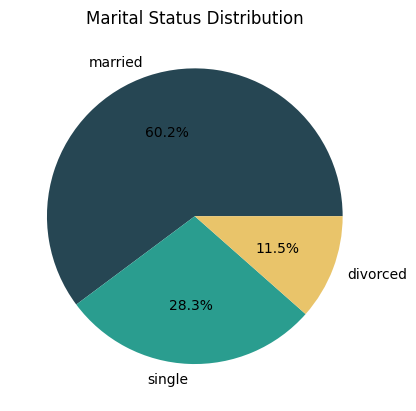

In [ ]:
df['marital'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors =['#264653', '#2A9D8F', '#E9C46A'])
plt.title("Marital Status Distribution")
plt.ylabel("")
plt.show()

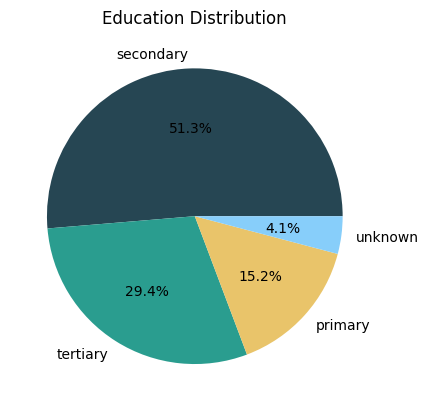

In [ ]:
df['education'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors =['#264653', '#2A9D8F', '#E9C46A' , '#87CEFA'])

plt.ylabel("")
plt.title("Education Distribution")
plt.show()

Text(0, 0.5, '')

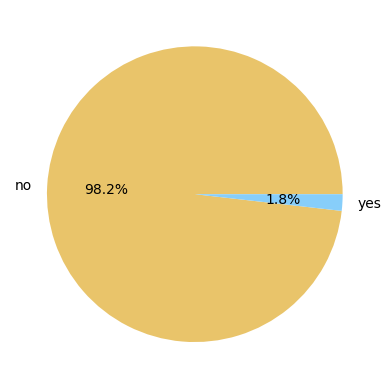

In [ ]:
df['default'].value_counts(normalize=True) * 100
df['default'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors =['#E9C46A' , '#87CEFA'])
plt.ylabel("")


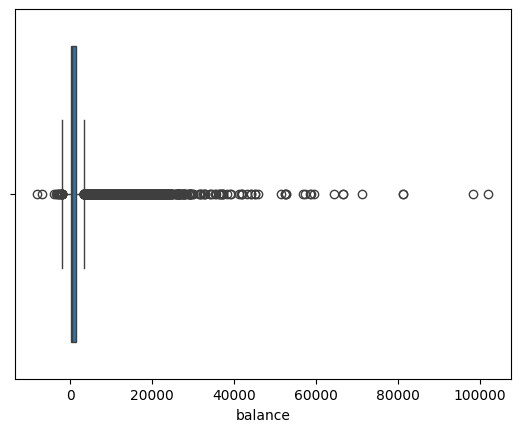

In [ ]:
sns.boxplot(x=df['balance'])
plt.show()

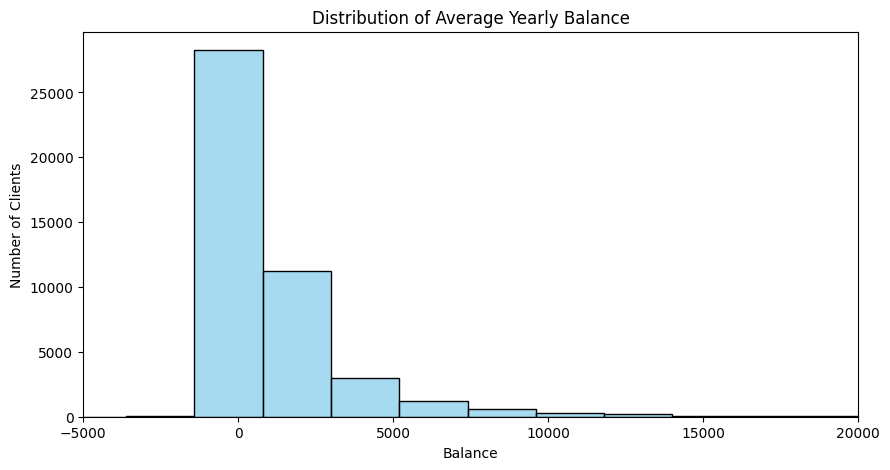

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['balance'],
    bins=50,
    color='skyblue',
    edgecolor='black'
)

plt.xlim(-5000, 20000)

plt.title("Distribution of Average Yearly Balance")
plt.xlabel("Balance")
plt.ylabel("Number of Clients")

plt.show()

Text(0, 0.5, '')

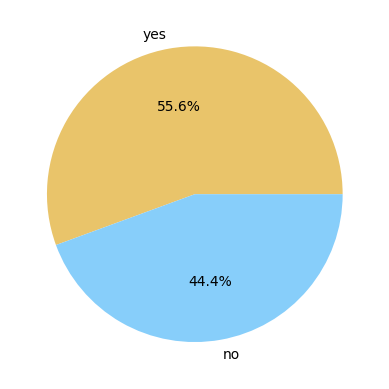

In [ ]:
df['housing'].value_counts()
df['housing'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors =['#E9C46A' ,'#87CEFA'])
plt.ylabel("")


Text(0.5, 1.0, 'Contact Distribution')

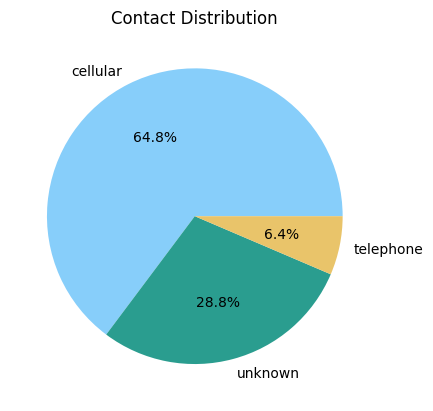

In [ ]:
df['contact'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors =['#87CEFA', '#2A9D8F', '#E9C46A'])
plt.ylabel("")
plt.title("Contact Distribution")

Text(0.5, 0, 'DAY')

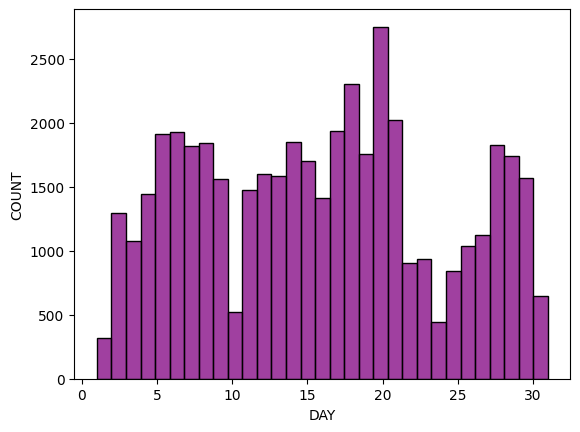

In [ ]:
sns.histplot(df['day'], bins=31, color="purple")
plt.ylabel("COUNT")
plt.xlabel("DAY")

Text(0, 0.5, 'COUNT')

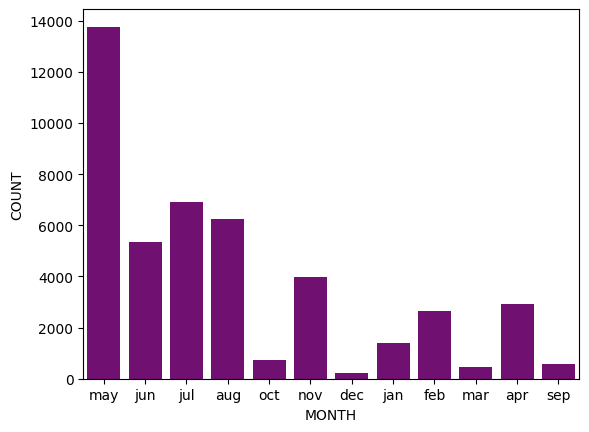

In [ ]:
sns.countplot(x='month', data=df,color = "purple")
plt.xlabel("MONTH")
plt.ylabel("COUNT")

Text(0, 0.5, 'COUNT')

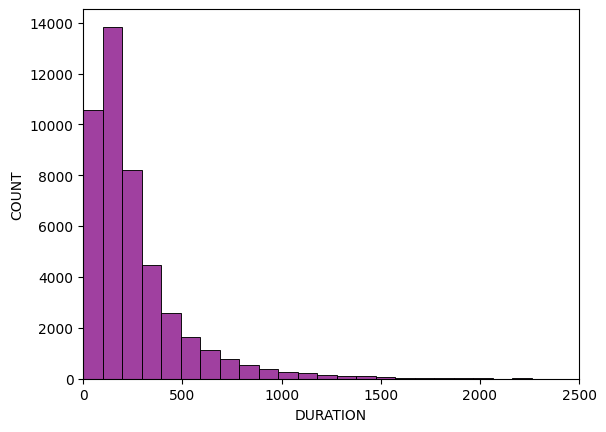

In [ ]:
sns.histplot(df['duration'], bins=50,color = "purple")
plt.xlim(0, 2500)
plt.xlabel("DURATION")
plt.ylabel("COUNT")

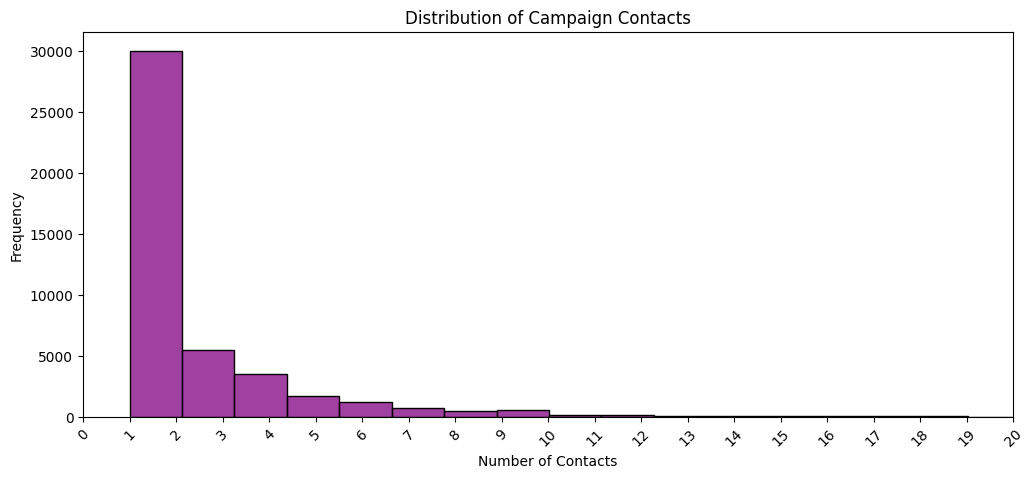

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['campaign'],
    bins=55,
    color='purple',
    edgecolor='black'
)

plt.xlim(0,20)

plt.xticks(range(0,21,1), rotation=45)

plt.title("Distribution of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df['campaign'].value_counts()

,count
campaign,
1,17544
2,12505
3,5521
4,3522
5,1764
6,1291
7,735
8,540
9,327


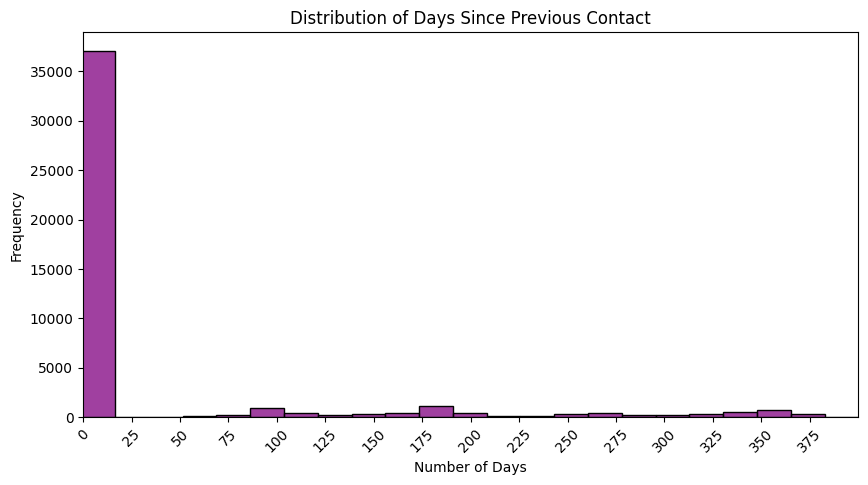

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['pdays'],
    bins=50,
    color='purple',
    edgecolor='black'
)
plt.xlim(0,400)
plt.xticks(range(0,400,25), rotation=45)

plt.title("Distribution of Days Since Previous Contact")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df['pdays'].value_counts()

,count
pdays,
-1,36954
182,167
92,147
183,126
91,126
...,...
749,1
769,1
587,1


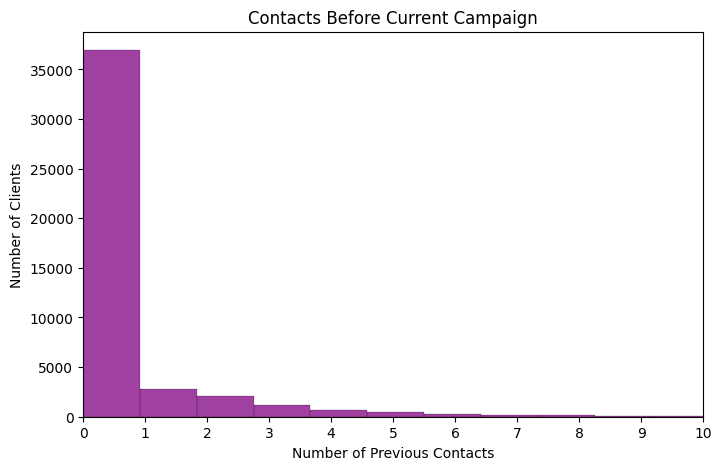

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["previous"], bins=300, color="purple")
plt.xticks(range(0, 11, 1))
plt.xlim(0,10)
plt.title("Contacts Before Current Campaign")
plt.xlabel("Number of Previous Contacts")
plt.ylabel("Number of Clients")
plt.show()


Previous marketing campaign outcomes:
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


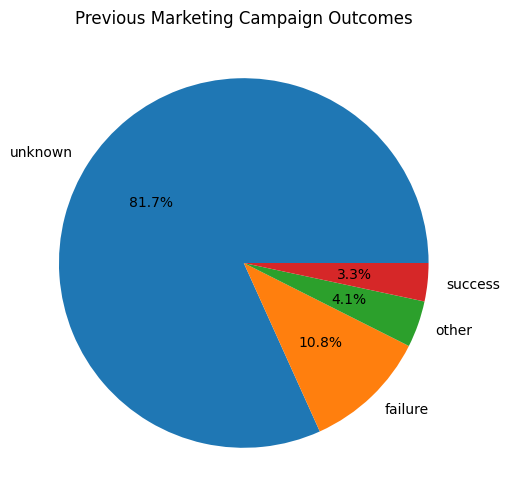

In [ ]:
print("Previous marketing campaign outcomes:")
print(df["poutcome"].value_counts())

plt.figure(figsize=(6, 6))
df["poutcome"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Previous Marketing Campaign Outcomes")
plt.ylabel("")
plt.show()

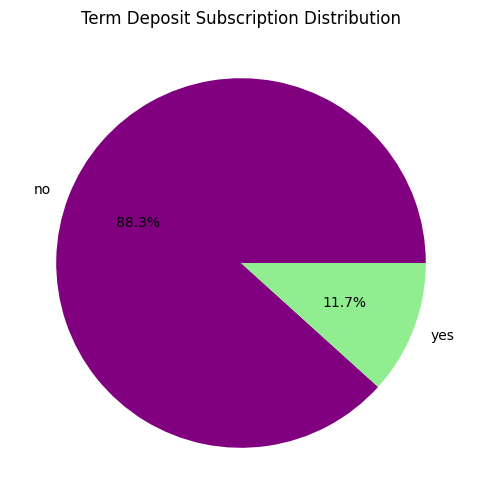

In [ ]:
plt.figure(figsize=(6, 6))
df["y"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["purple", "lightgreen"]
)

plt.title("Term Deposit Subscription Distribution")
plt.ylabel("")
plt.show()

In [ ]:
ml_data = df.copy()

# Convert categorical text columns into numbers.
label_encoder = LabelEncoder()

for column in ml_data.columns:
    if ml_data[column].dtype == "object":
        ml_data[column] = label_encoder.fit_transform(ml_data[column])

print("Data after converting text columns to numbers:")
print(ml_data.head())
print()

Data after converting text columns to numbers:
   age  job  marital  marital_status  education  default  balance  housing  \
0   58    4        1               1          2        0     2143        1   
1   44    9        2               2          1        0       29        1   
2   33    2        1               1          1        0        2        1   
3   47    1        1               1          3        0     1506        1   
4   33   11        2               2          3        0        1        0   

   loan  contact  day  month  day_month  duration  campaign  pdays  previous  \
0     0        2    5      8        271       261         1     -1         0   
1     0        2    5      8        271       151         1     -1         0   
2     1        2    5      8        271        76         1     -1         0   
3     0        2    5      8        271        92         1     -1         0   
4     0        2    5      8        271       198         1     -1         0   

   

In [ ]:
X = ml_data.drop("y", axis=1)
y = ml_data["y"]



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print()


Training rows: 36168
Testing rows: 9043



In [ ]:
logistic_model = LogisticRegression(max_iter=5000)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)


logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [ ]:
logistic_prediction = logistic_model.predict(X_test)
decision_tree_prediction = decision_tree_model.predict(X_test)
random_forest_prediction = random_forest_model.predict(X_test)


print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, logistic_prediction))
print()

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, decision_tree_prediction))
print()

print("Random Forest Accuracy:")
print(accuracy_score(y_test, random_forest_prediction))
print()

Logistic Regression Accuracy:
0.8865420767444432

Decision Tree Accuracy:
0.8762578790224483

Random Forest Accuracy:
0.900364923144974



In [ ]:
print("Classification report for Random Forest:")
print(classification_report(y_test, random_forest_prediction))
print()

print("Confusion matrix for Random Forest:")
print(confusion_matrix(y_test, random_forest_prediction))
print()


print("Project completed successfully")

Classification report for Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.63      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043


Confusion matrix for Random Forest:
[[7691  261]
 [ 640  451]]

Project completed successfully
